## Looking at centromere haplotype structure

Loading libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Reading in centromere haplotypes

Master file: one row for each chromosome from each sample in the 1000 genomes dataset

In [3]:
centromere_master = pd.read_csv("/home/ih233/data/projects/cenhap_120725/cenhaps.1kg.imputed.clades.v2.tsv", sep = "\t")

In [4]:
centromere_master

,#chrom,sample,pop,superpop,hap1_1,hap2_1,score1,ones_,hap1_2|hap2_2|score2|hap1_3|hap2_3|score3,hap1_1|pop|superpop|cut_clade_count,hap2_1|pop|superpop|cut_clade_count
0,chr10,HG00096,GBR,EUR,HG00290#2,NA20129#2,795713.0,203448,HG00290#2|HG00290#2|795666.0|HG00290#2|NA20850...,HG00290#2|FIN|EUR|chr10_1_5_423|chr10_2_7_139|...,NA20129#2|ASW|AFR|chr10_1_5_423|chr10_2_7_139|...
1,chr11,HG00096,GBR,EUR,HG00253#2,HG01891#1,1052488.0,353219,HG00133#2|HG01891#1|1052223.0|HG01891#1|HG0273...,HG00253#2|GBR|EUR|chr11_1_5_135|chr11_2_7_47|c...,HG01891#1|ACB|AFR|chr11_1_7_205|chr11_2_9_205|...
2,chr12,HG00096,GBR,EUR,HG00097#1,HG00253#2,489816.0,57302,HG00097#1|HG00146#2|489726.0|HG00097#1|HG01081...,HG00097#1|GBR|EUR|chr12_1_1_446|chr12_2_1_446|...,HG00253#2|GBR|EUR|chr12_1_1_446|chr12_2_1_446|...
3,chr13,HG00096,GBR,EUR,HG01496#1,NA20809#2,219379.0,29970,HG01496#1|NA20752#2|218383.0|HG00320#1|HG01496...,HG01496#1|CLM|AMR|chr13_1_23_9|chr13_2_39_5|ch...,NA20809#2|TSI|EUR|chr13_1_24_358|chr13_2_51_36...
4,chr14,HG00096,GBR,EUR,HG02004#1,NA20799#1,630307.0,44186,HG02004#1|NA21093#2|629881.0|HG01252#1|NA20799...,HG02004#1|PEL|AMR|chr14_1_6_423|chr14_2_10_393...,NA20799#1|TSI|EUR|chr14_1_6_423|chr14_2_10_393...
...,...,...,...,...,...,...,...,...,...,...,...
76843,chr7,NA21144,GIH,SAS,NA21144#1,NA21144#2,881795.0,127113,HG01175#1|NA21144#1|877986.0|NA20850#1|NA21144...,NA21144#1|GIH|SAS|chr7_1_3_22|chr7_2_3_22|chr7...,NA21144#2|GIH|SAS|chr7_1_4_398|chr7_2_4_93|chr...
76844,chr8,NA21144,GIH,SAS,NA21093#1,NA21144#1,489677.0,195575,NA21144#1|NA21144#2|489670.0|NA21093#1|NA21106...,NA21093#1|GIH|SAS|chr8_1_8_174|chr8_2_11_173|c...,NA21144#1|GIH|SAS|chr8_1_9_135|chr8_2_15_125|c...
76845,chr9,NA21144,GIH,SAS,NA21144#1,NA21144#2,1171104.0,192240,HG00099#1|NA21144#1|1164230.0|NA21093#1|NA2114...,NA21144#1|GIH|SAS|chr9_1_35_243|chr9_2_61_193|...,NA21144#2|GIH|SAS|chr9_1_35_243|chr9_2_61_193|...
76846,chrX,NA21144,GIH,SAS,NA21144#1,NA21144#2,122166.0,21406,HG03927#2|NA21144#2|121690.0|NA21106#1|NA21144...,NA21144#1|GIH|SAS|chrX_1_9_282|chrX_2_10_282|c...,NA21144#2|GIH|SAS|chrX_1_9_282|chrX_2_10_282|c...


In [50]:
# Getting set of all clade IDs from centromere master table
split_series = centromere_master["hap1_1|pop|superpop|cut_clade_count"].str.split("|")

# Slice last 6 elements and flatten lists into rows
flat_clades = split_series.str[-6:].explode()

# Drop missing values and get unique IDs
hap1_clade_ids = set(flat_clades.dropna())

In [51]:
# Getting set of all clade IDs from centromere master table
split_series = centromere_master["hap2_1|pop|superpop|cut_clade_count"].str.split("|")

# Slice last 6 elements and flatten lists into rows
flat_clades = split_series.str[-6:].explode()

# Drop missing values and get unique IDs
hap2_clade_ids = set(flat_clades.dropna())

In [52]:
# Taking union of hap1 and hap2 centromere haplotype sets
clade_ids = hap1_clade_ids.union(hap2_clade_ids)

Haplotype genotype calls: used as input in predictive modeling with FUSION

Want to understand the clade structure --> file should list all the clades/number of samples per clade

Table structure: rows = clade IDs, columns = samples, values = genotype dosages --> only really need to analyze the clade IDs to understand the clade structure

Might be worthwhile to look at the most common clades

Clade ID format: ex: chr10_3_3_10 --> CHROMOSOME_CUT_CLADE ID FOR CUT_NUMBER OF HPRC SAMPLES IN CLADE

In [5]:
centromere_genotypes = pd.read_csv("/gpfs/gibbs/pi/ycgh/lushjia/project/SV/AFGR/RNA/centromere/afgr.clade.sample.matrix.v2.tsv.gz", sep = "\t")

In [6]:
centromere_genotypes

,clade,NA19042,NA19315,NA18915,NA19451,NA19379,NA19346,NA19316,NA19041,NA19393,...,HG03189,HG03091,HG02629,HG03054,HG03372,HG03028,HG03169,HG03354,HG03126,HG02952
0,chr10_1_1_8,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
1,chr10_1_2_16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,chr10_1_3_12,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,chr10_1_4_3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,chr10_1_5_423,2,1,2,2,2,2,2,2,2,...,2,2,1,2,1,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8413,chrY_6_1_4,2,2,0,0,2,0,2,0,0,...,2,2,2,0,2,2,0,2,2,2
8414,chrY_6_2_2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8415,chrY_6_7_4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8416,chrY_6_8_2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
# Looking at samples from 1000 genomes included in the testset --> ask about how these were chosen
samples_in_testset = set()
samples_not_in_testset = set()
for sample in set(centromere_master["sample"]):
    if sample in centromere_genotypes.columns:
        samples_in_testset.add(sample)
    else:
        samples_not_in_testset.add(sample)

print("Number of total samples: " + str(len(set(centromere_master["sample"]))) + ", Number of samples in testset: " + str(len(samples_in_testset)) + ", Number of samples not in testset: " + str(len(samples_not_in_testset)))

Number of total samples: 3202, Number of samples in testset: 430, Number of samples not in testset: 2772


Building dictionary of clade structure

chromosomes --> cut --> cut IDs --> samples per cut ID

In [55]:
haplotype_dict = {}

for clade_id in clade_ids:
    chromosome, cut, cut_id, sample_count = clade_id.split("_")
    cut = int(cut)
    cut_id = int(cut_id)
    sample_count = int(sample_count)
    # Adding to dict
    if chromosome not in haplotype_dict.keys():
        haplotype_dict.update({chromosome: {cut: {cut_id: sample_count}}})
    else:
        if cut not in haplotype_dict.get(chromosome).keys():
            haplotype_dict.get(chromosome).update({cut: {cut_id: sample_count}})
        else:
            if cut_id not in haplotype_dict.get(chromosome).get(cut).keys():
                haplotype_dict.get(chromosome).get(cut).update({cut_id: sample_count})
            else:
                print("Multiple cut ids! For: " + chromosome + ", " + "cut: " + cut + ", " + "cut ID: " + cut_id)


Writing function to produce plot that shows the number of samples in each cut ID. Either:
- Provide both chromosome and cut to generate single panel
- Provide just chromosome and generate a 6-panel plot, one per cut level

In [62]:
# Single panel for given chromosome and cut level
def plot_sample_counts_cut(chromosome, cut):
    plot_df = pd.DataFrame([haplotype_dict.get(chromosome).get(cut)]).transpose().reset_index().rename(columns={"index": "Cut ID", 0: "Sample Count"})
    sns.barplot(x = "Cut ID", y = "Sample Count", data = plot_df)
    plt.title(chromosome + ", cut: " + str(cut))
    plt.tight_layout()
    plt.show()

In [64]:
# Multi-panel plot for given chromosome (each panel is a different cut level)
def plot_sample_counts_chr(chromosome):
    # Building plot df
    dfs = []
    for cut in haplotype_dict.get(chromosome).keys():
        df = pd.DataFrame([haplotype_dict.get(chromosome).get(cut)]).transpose().reset_index().rename(columns={"index": "Cut ID", 0: "Sample Count"})
        df["cut"] = cut
        dfs.append(df)
    plot_df = pd.concat(dfs, ignore_index=True)
    # Making multi-panel plot
    g = sns.FacetGrid(plot_df, col = "cut", col_wrap = 3, sharex = False, height = 4, aspect = 1)
    g.map_dataframe(plt.bar, x = "Cut ID", height = "Sample Count")
    g.set_axis_labels(x_var="Cut ID", y_var="HPRC Sample Count")
    g.figure.suptitle(chromosome)
    plt.tight_layout()
    plt.show()


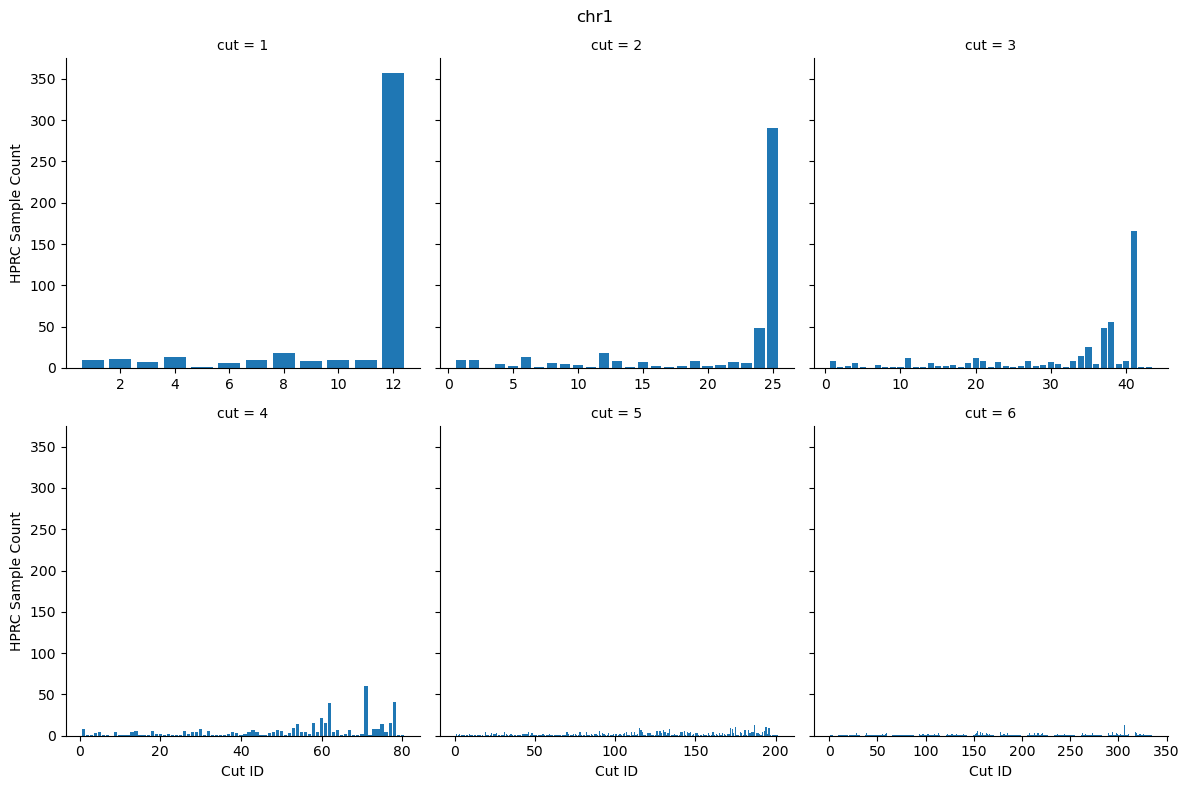

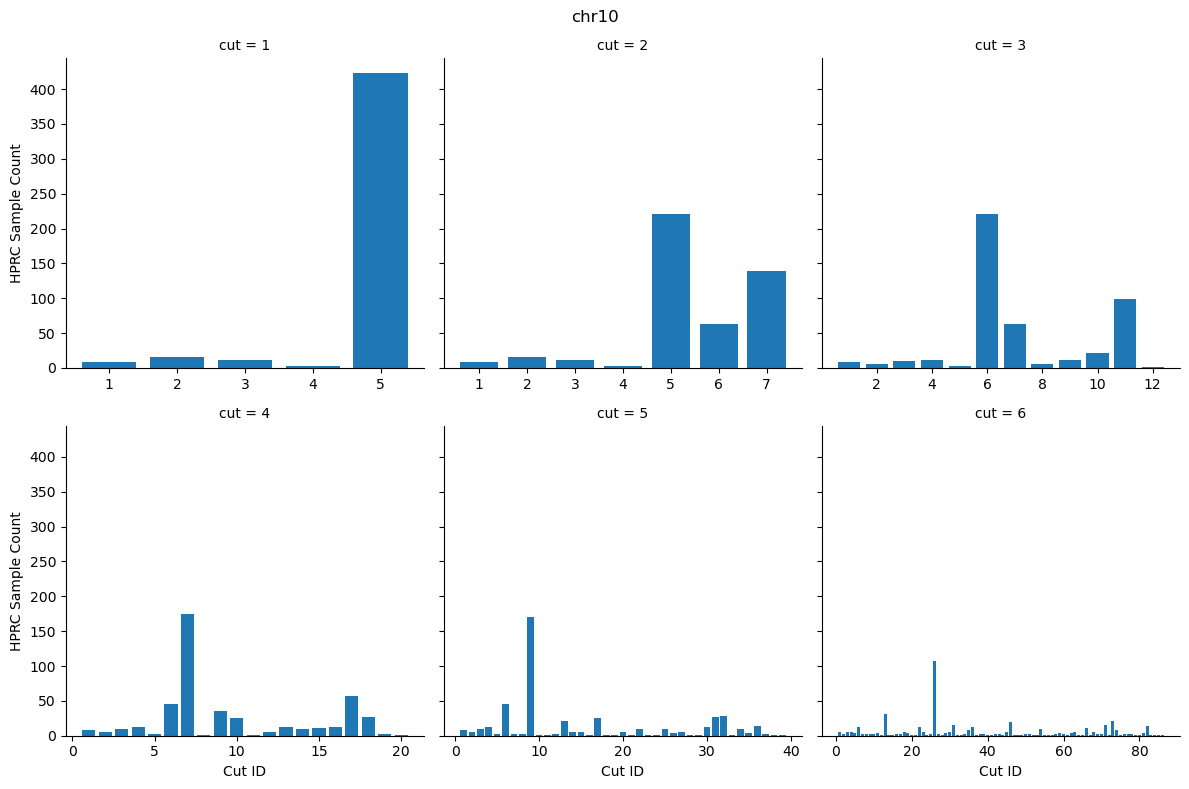

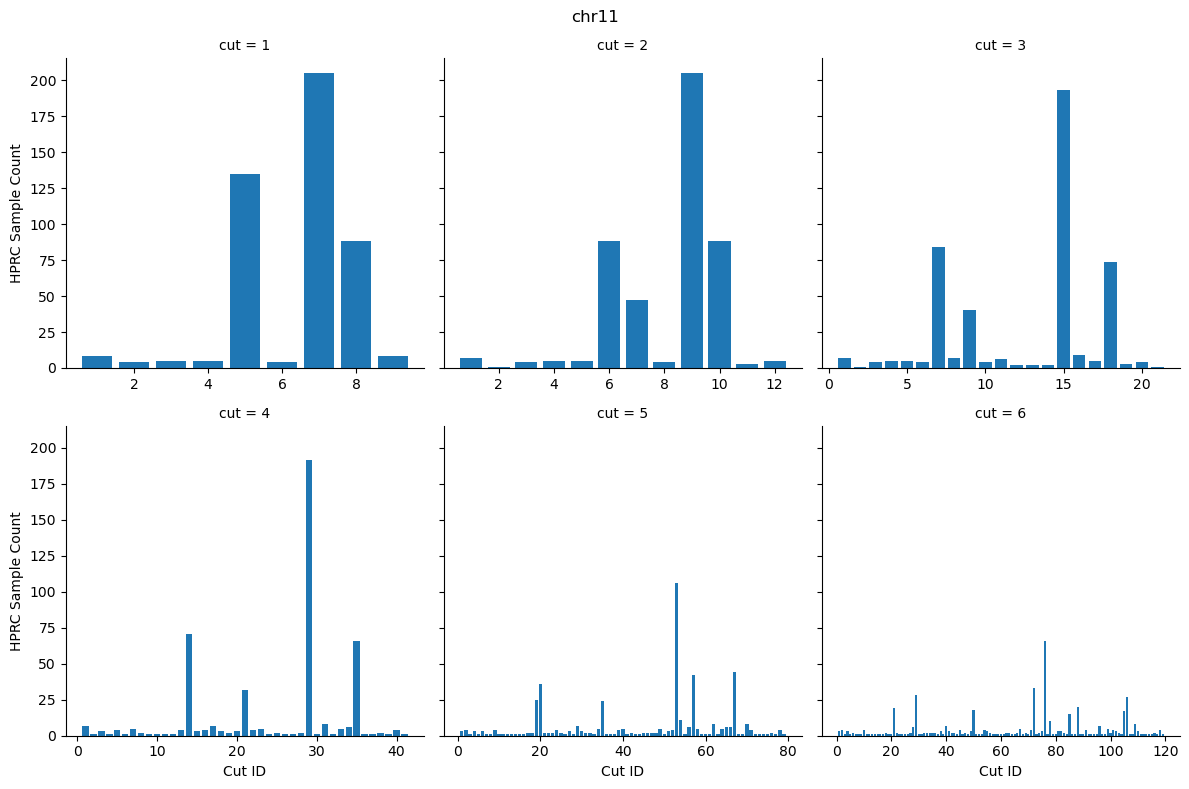

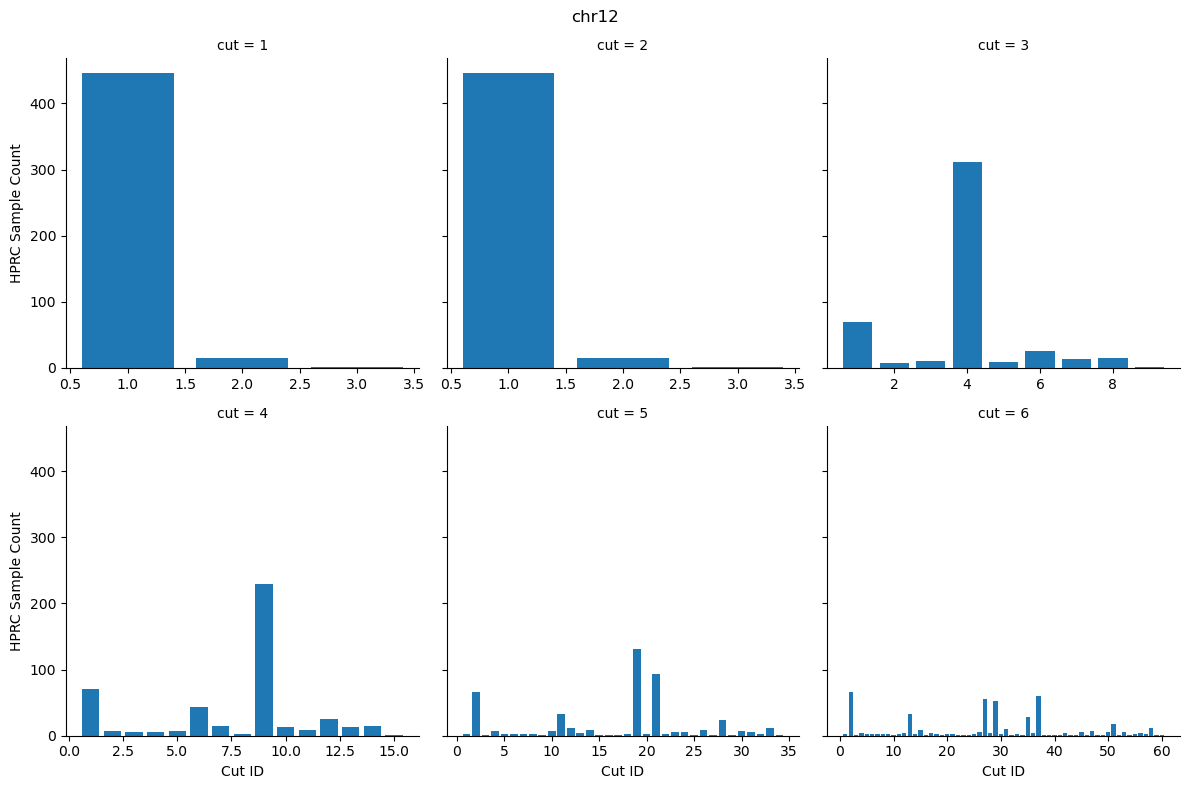

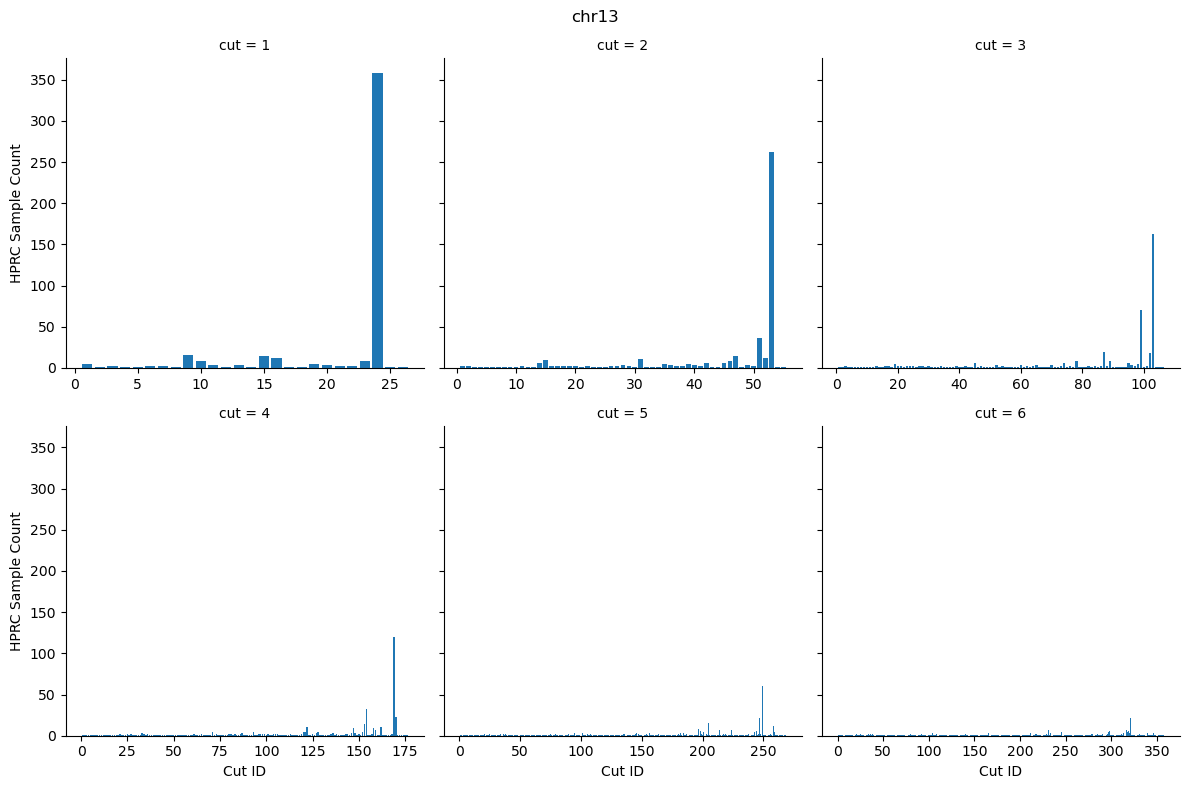

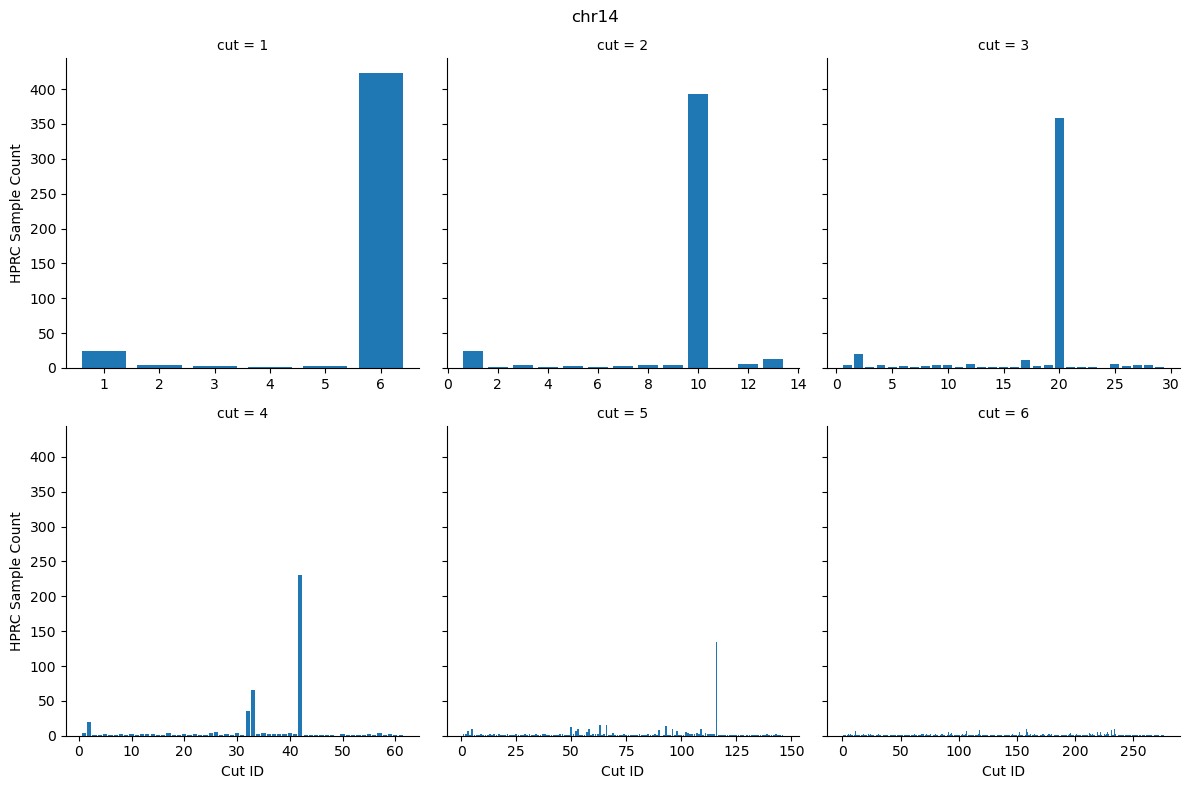

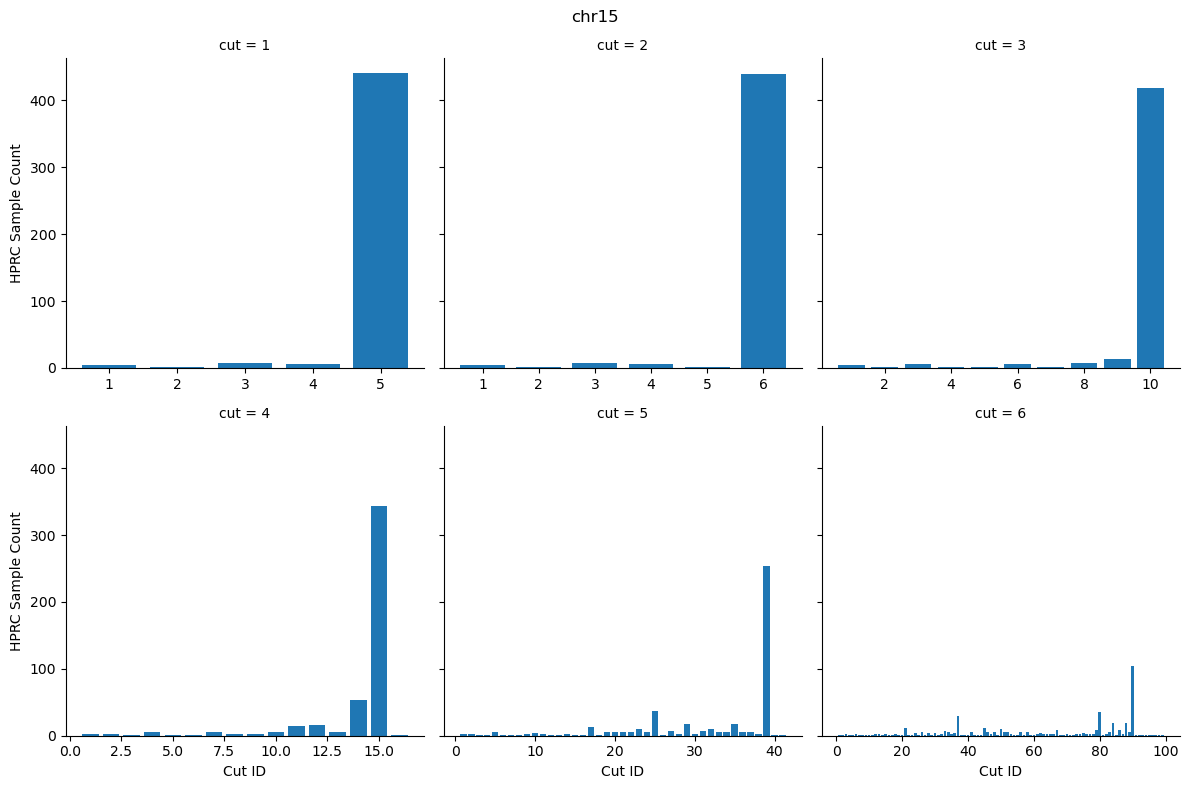

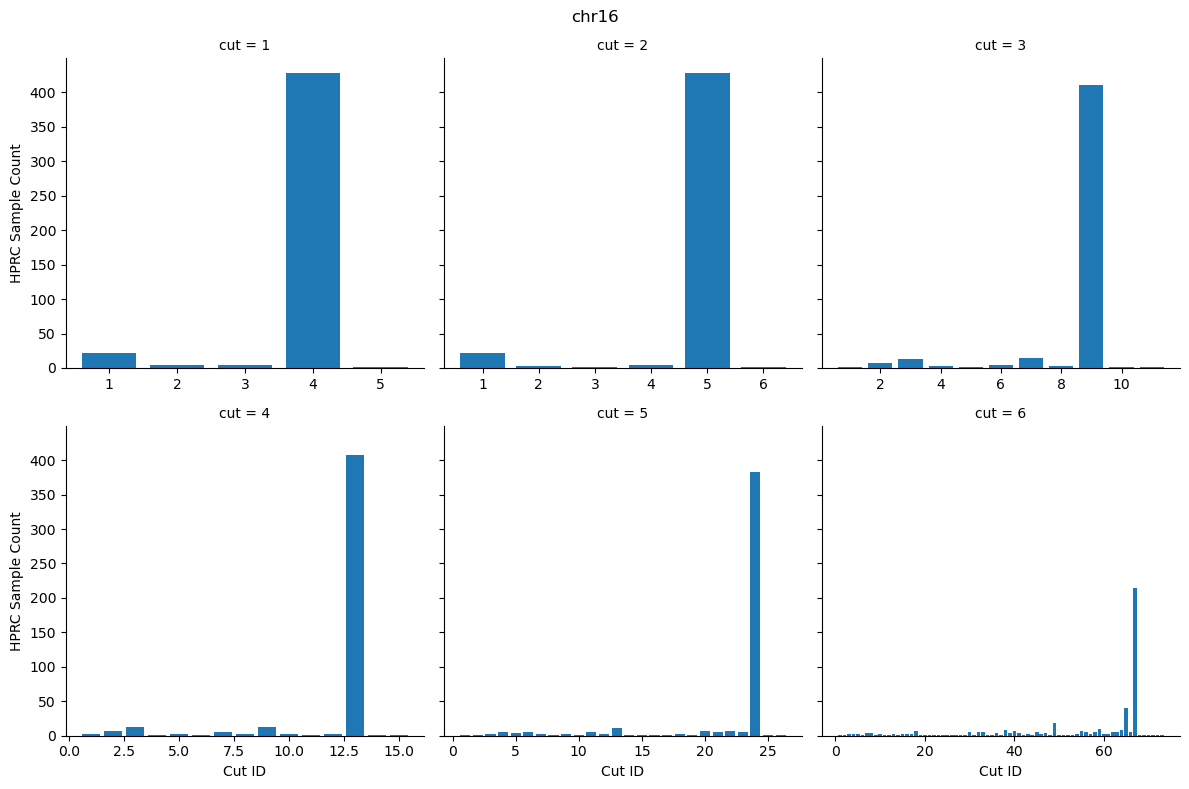

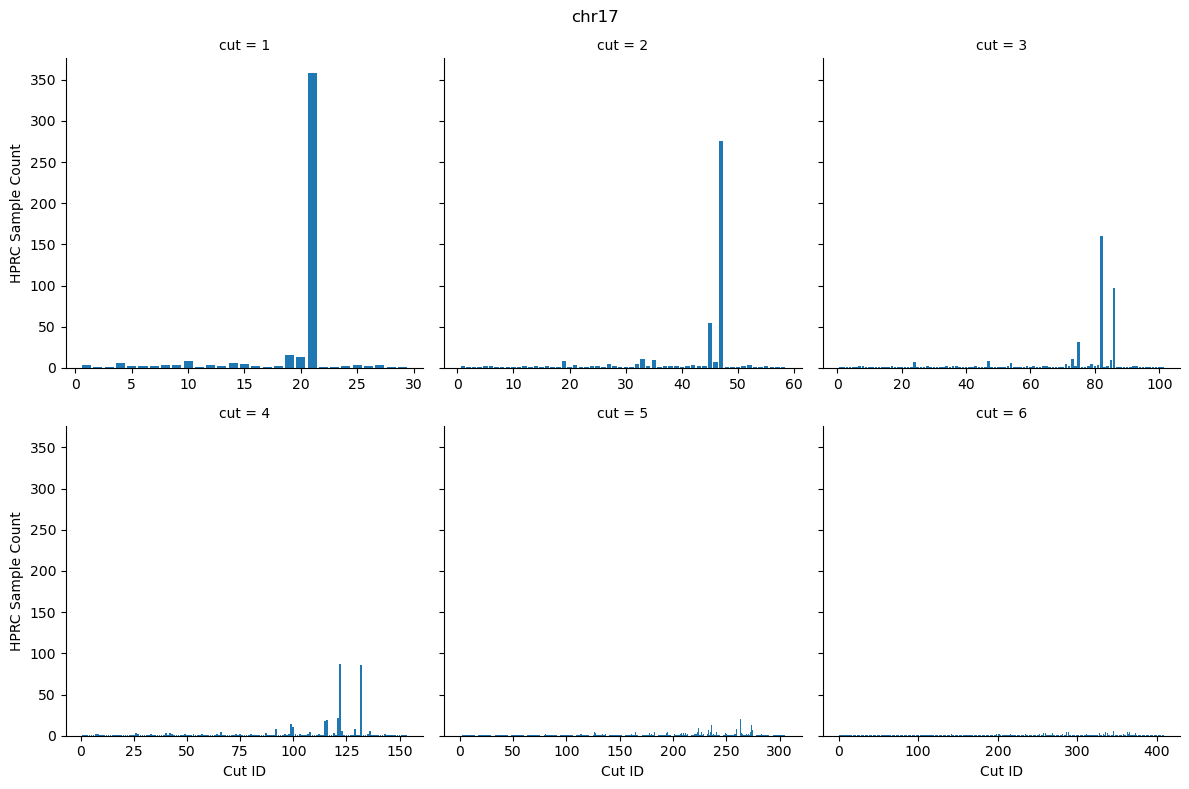

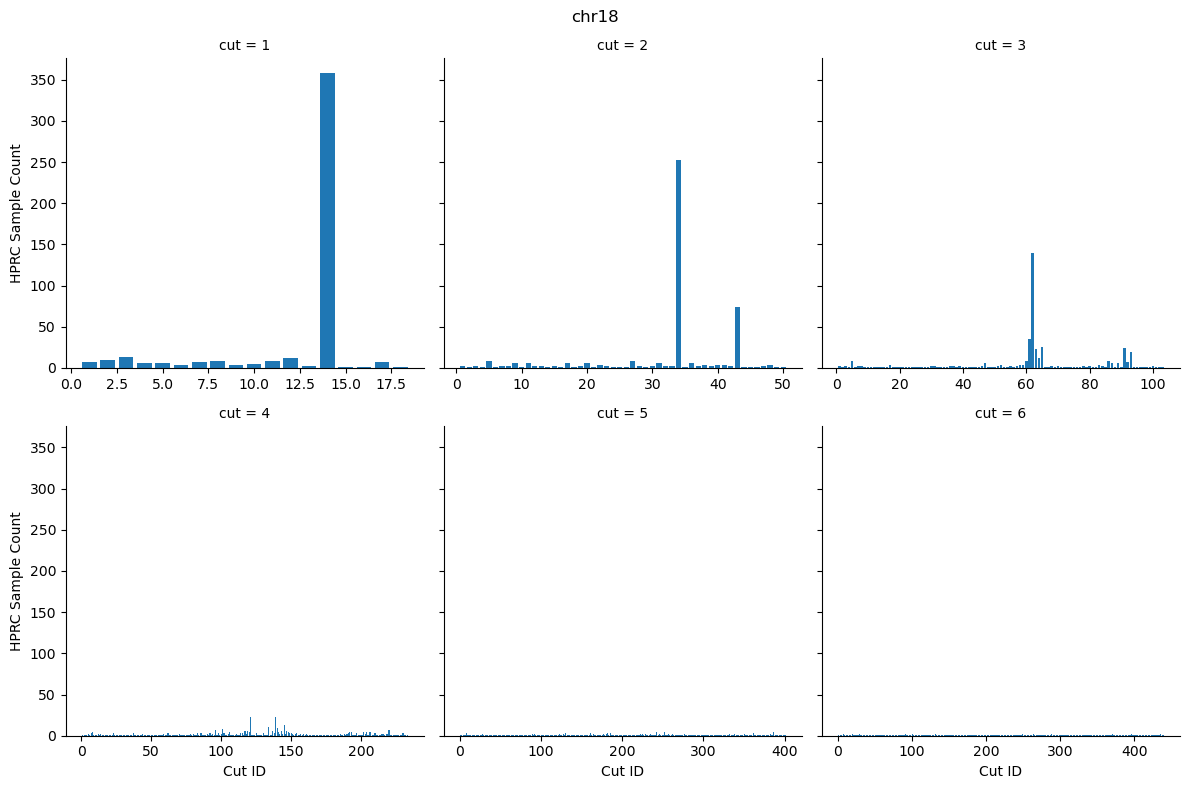

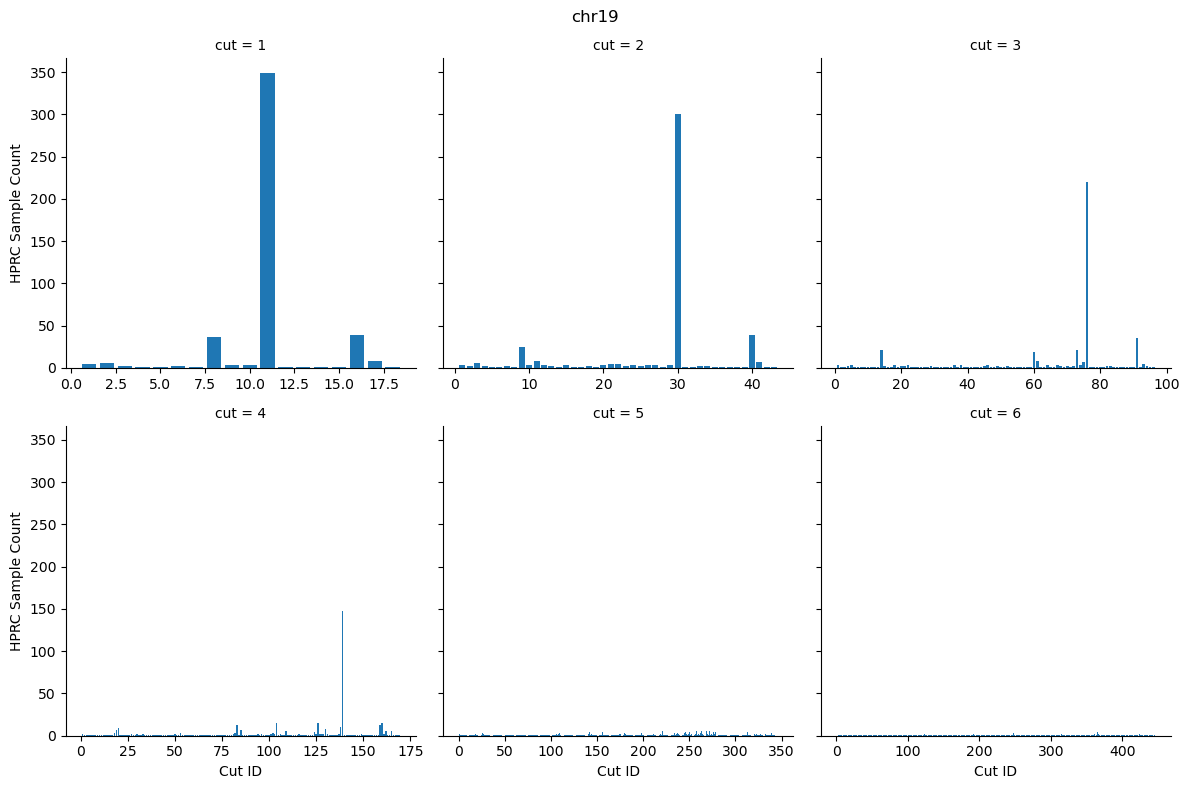

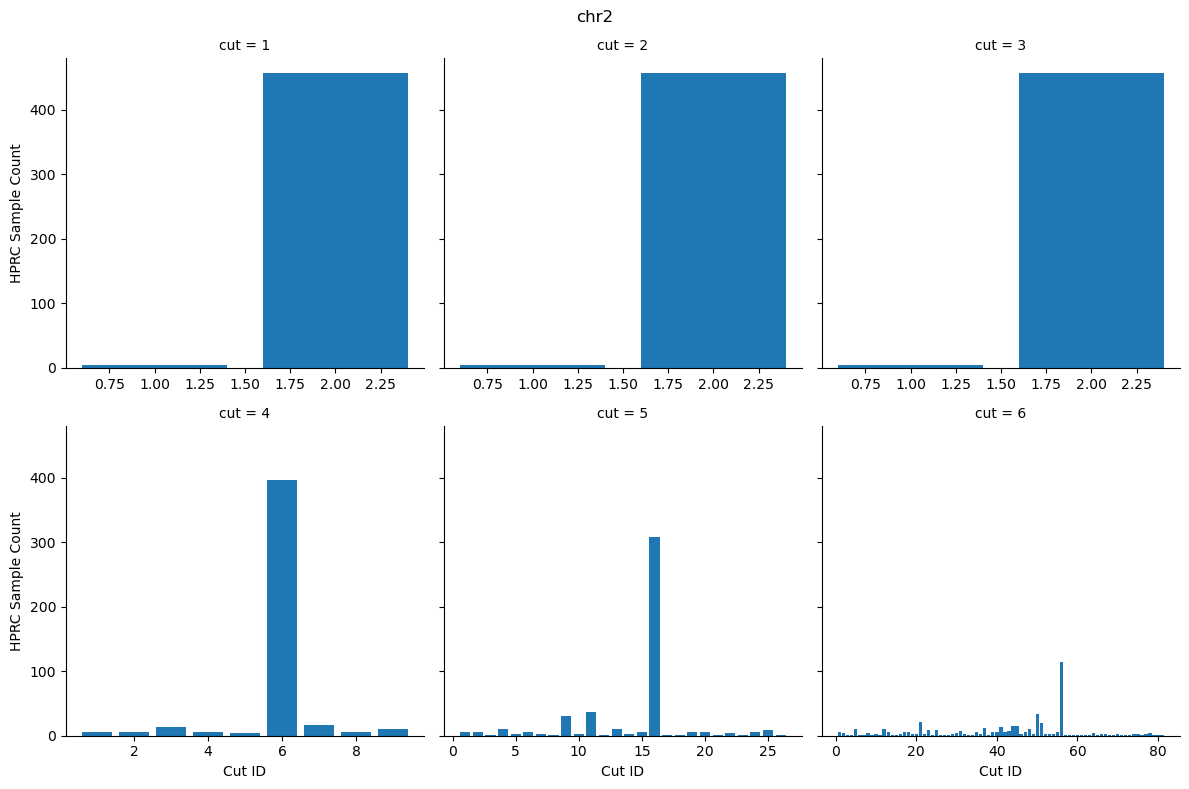

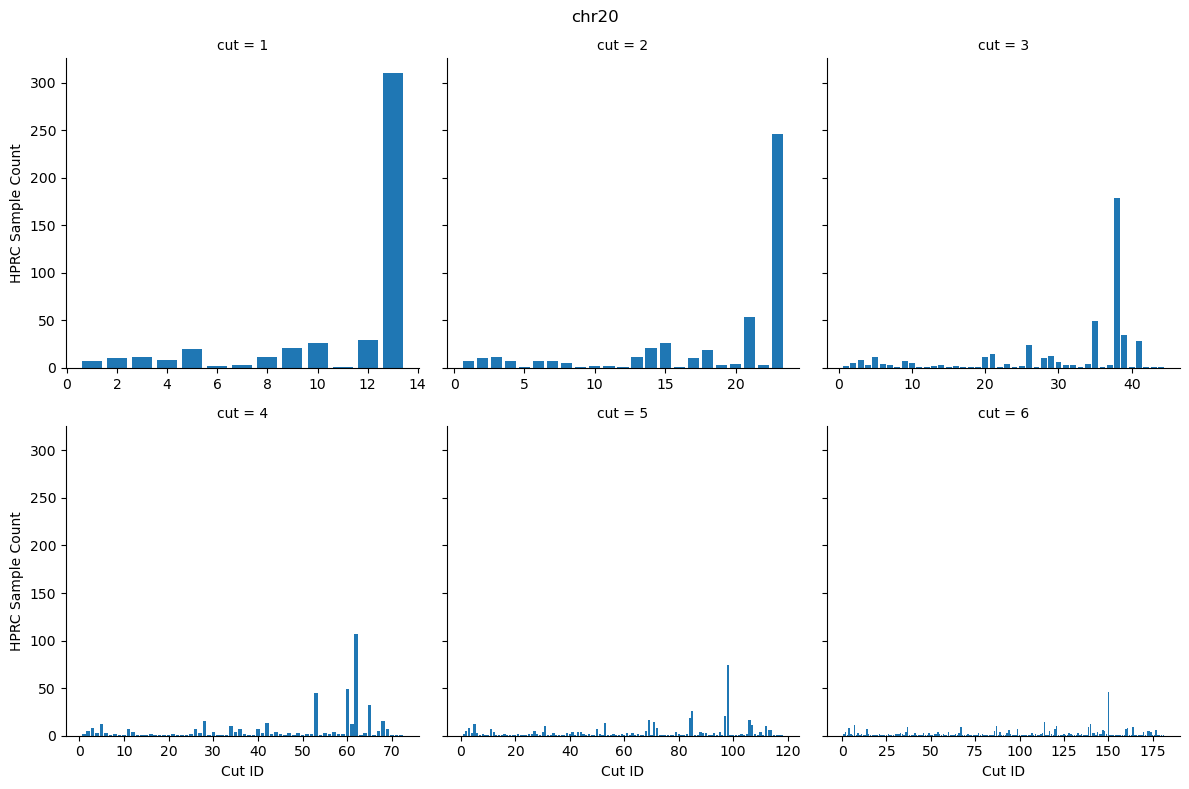

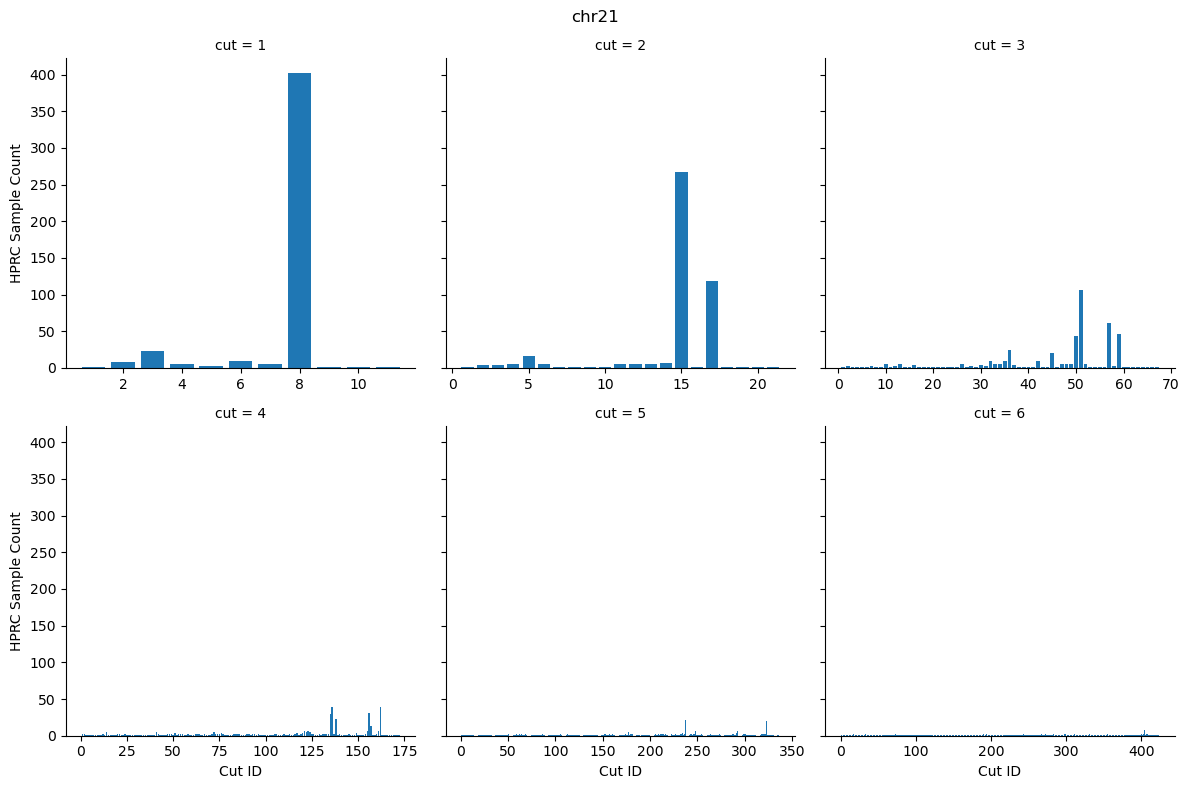

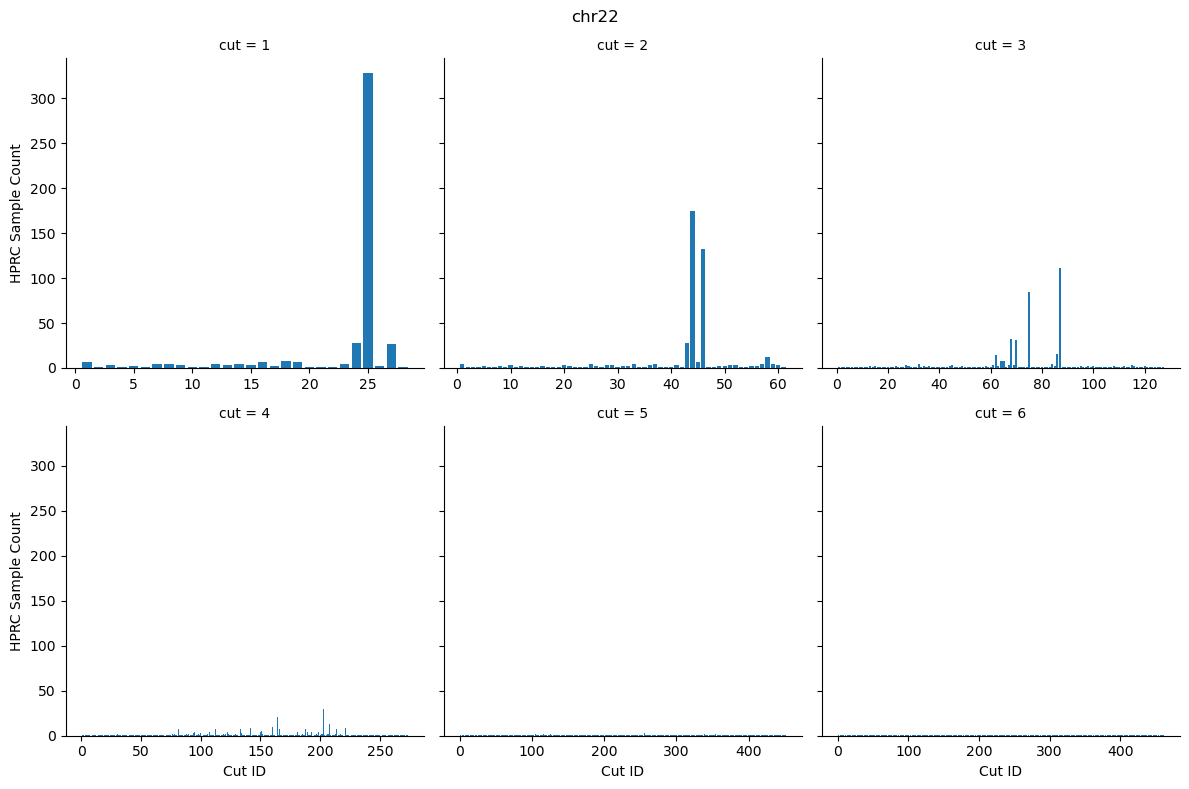

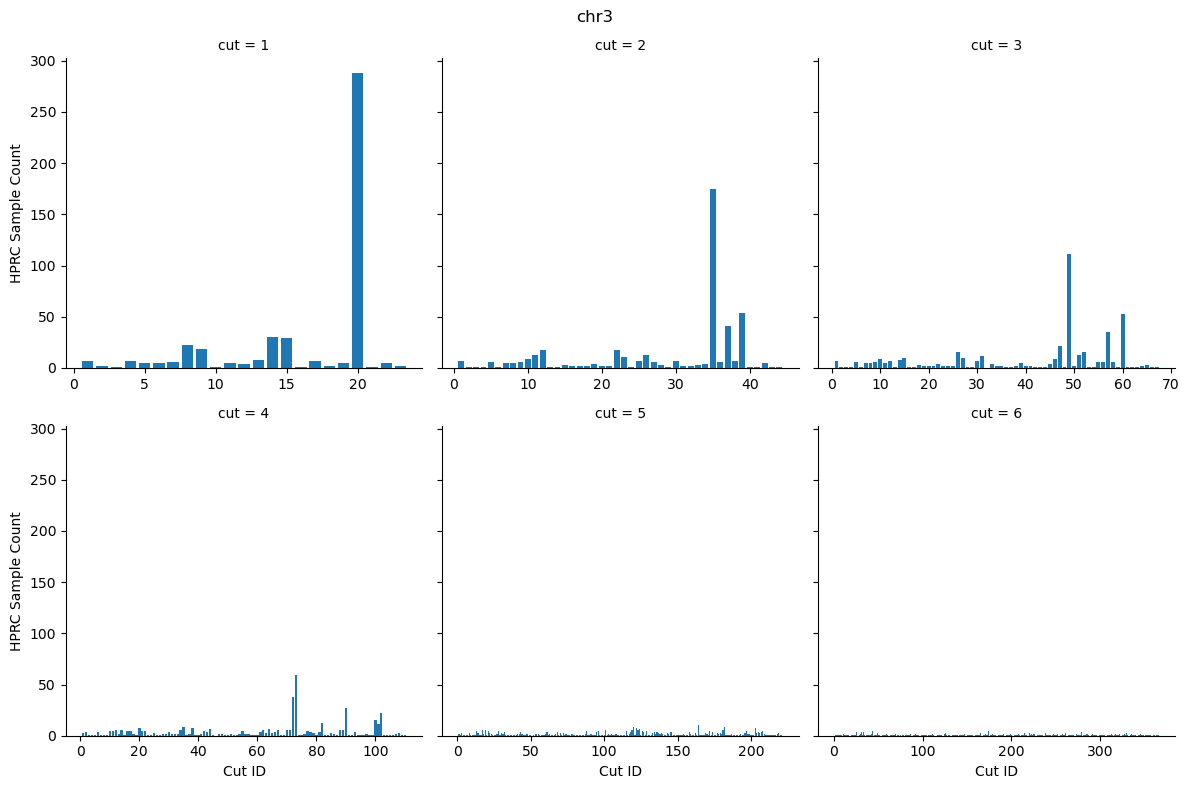

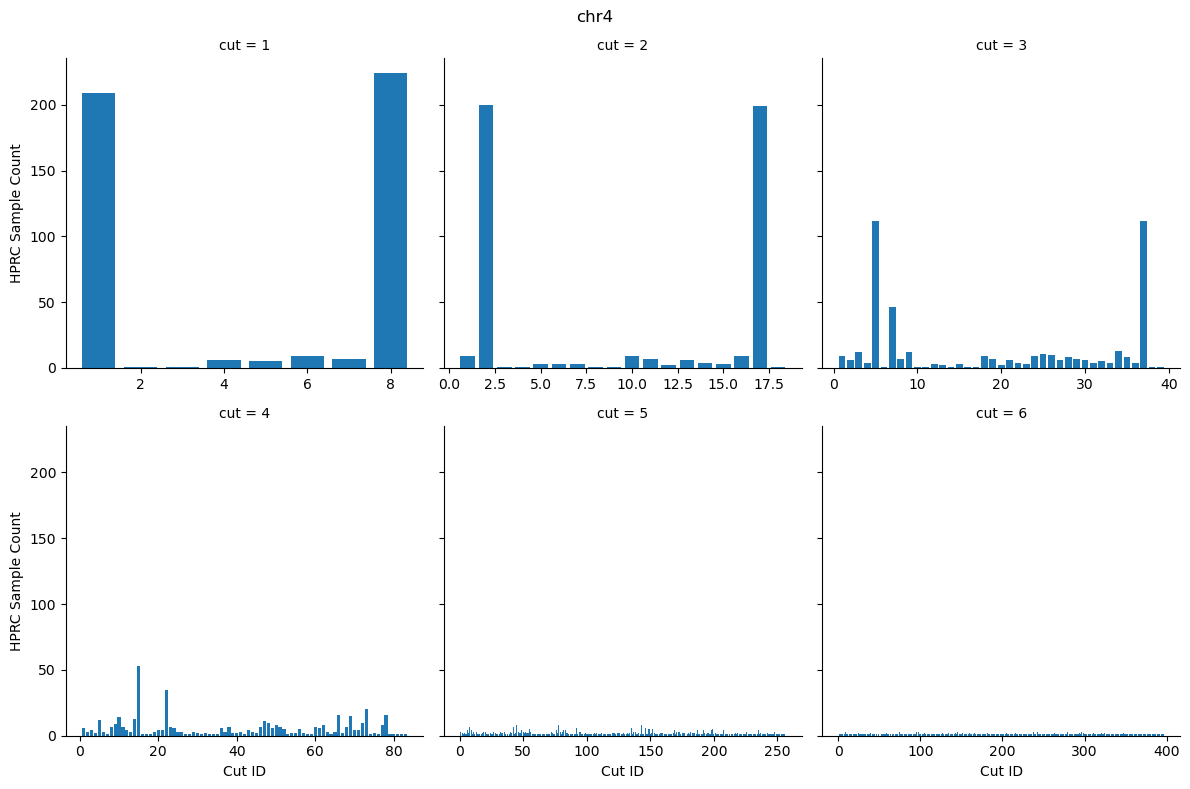

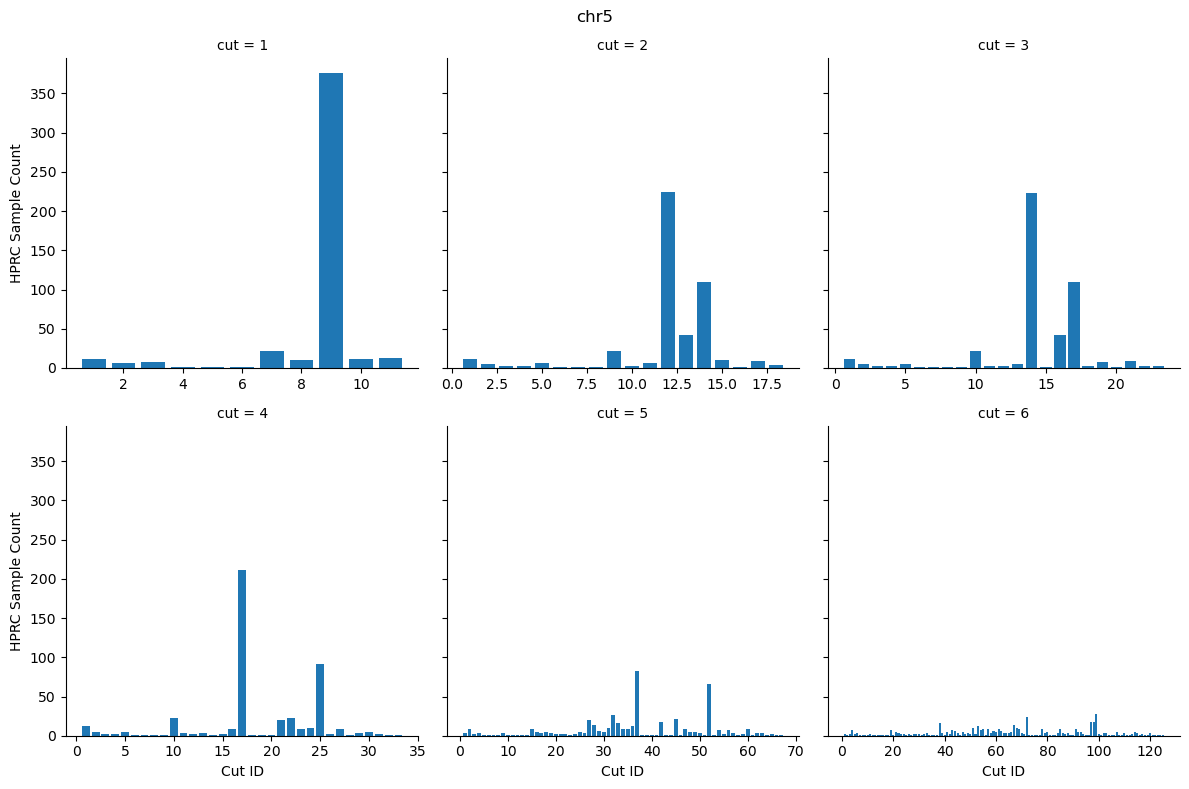

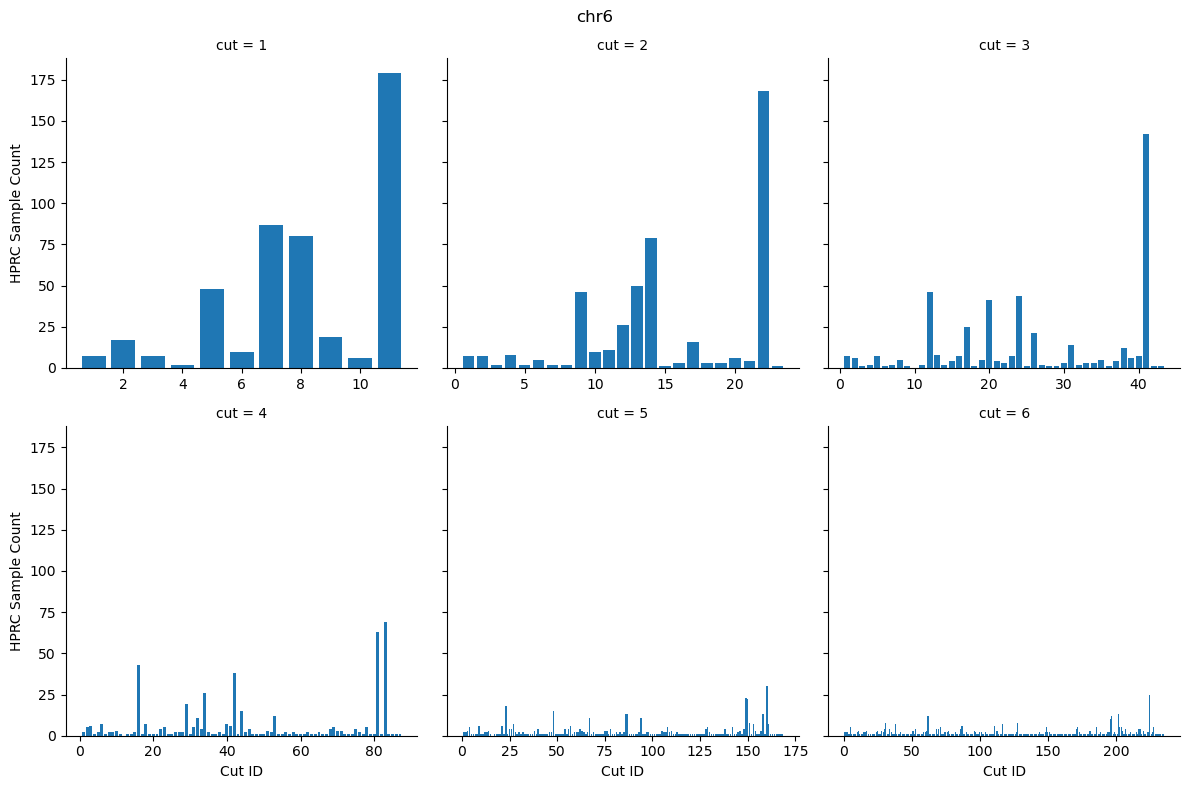

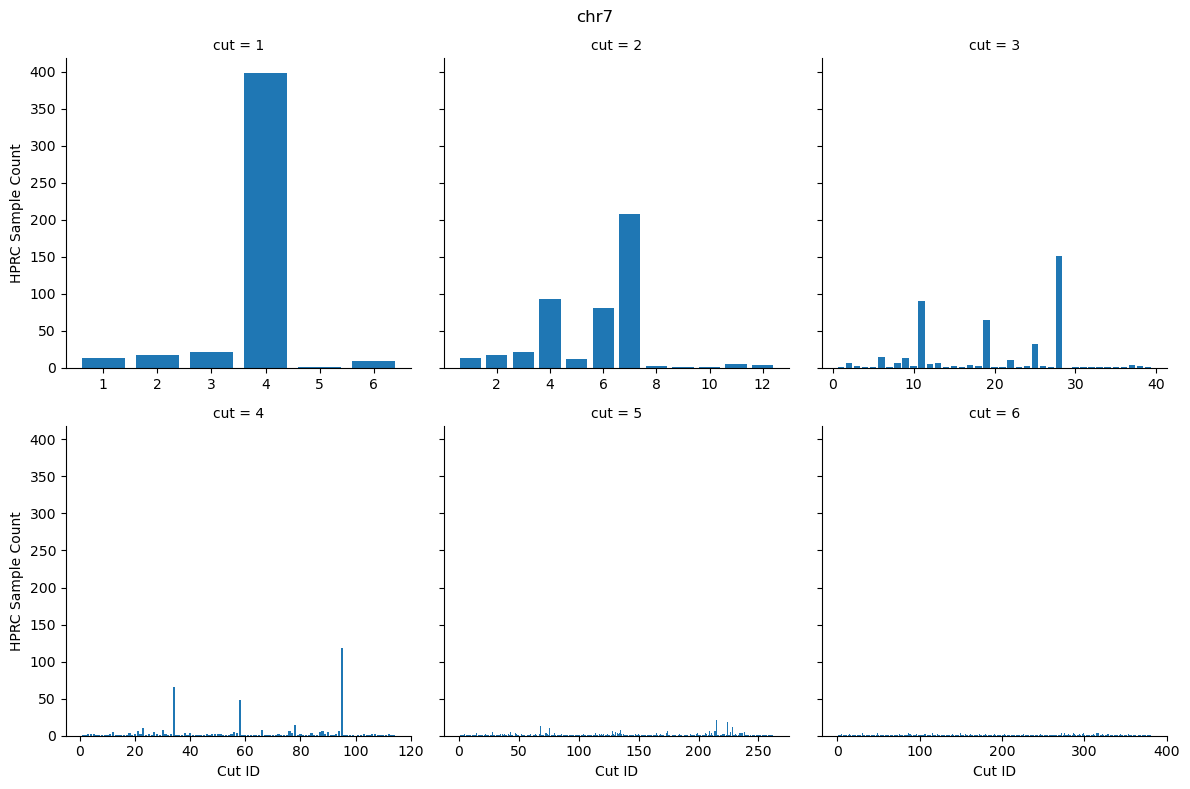

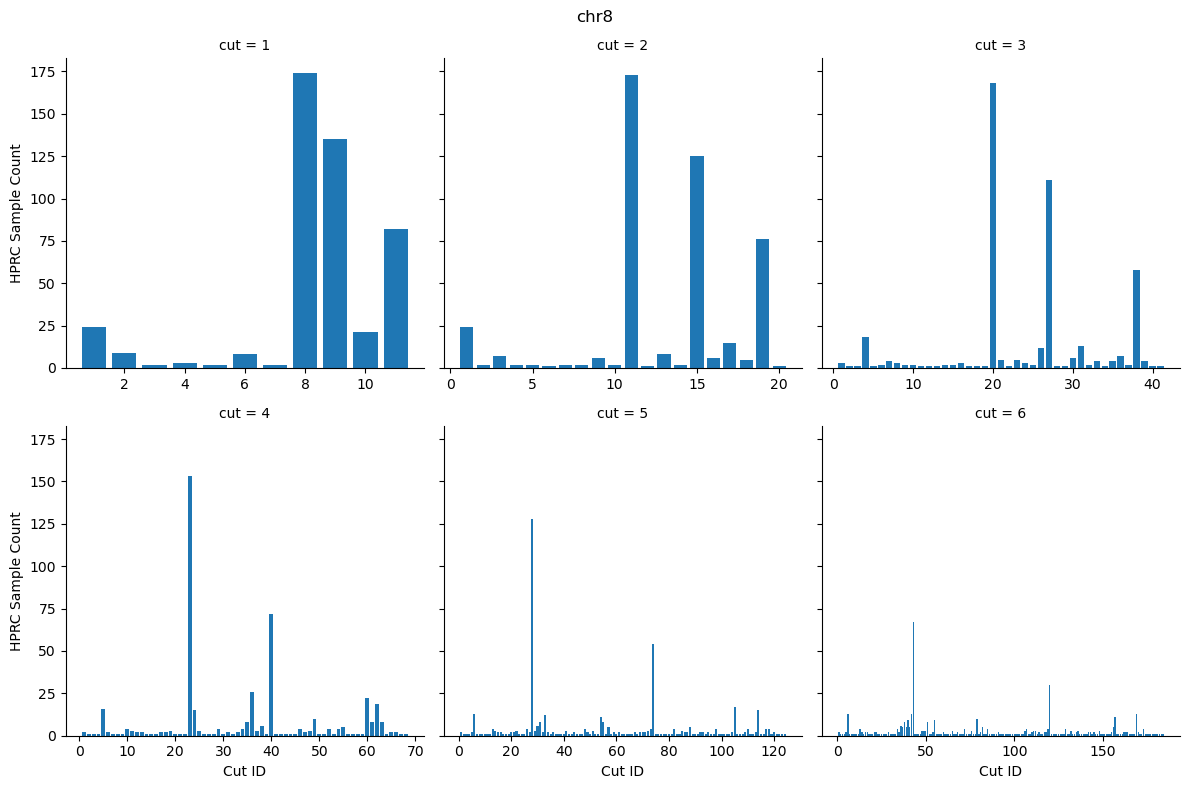

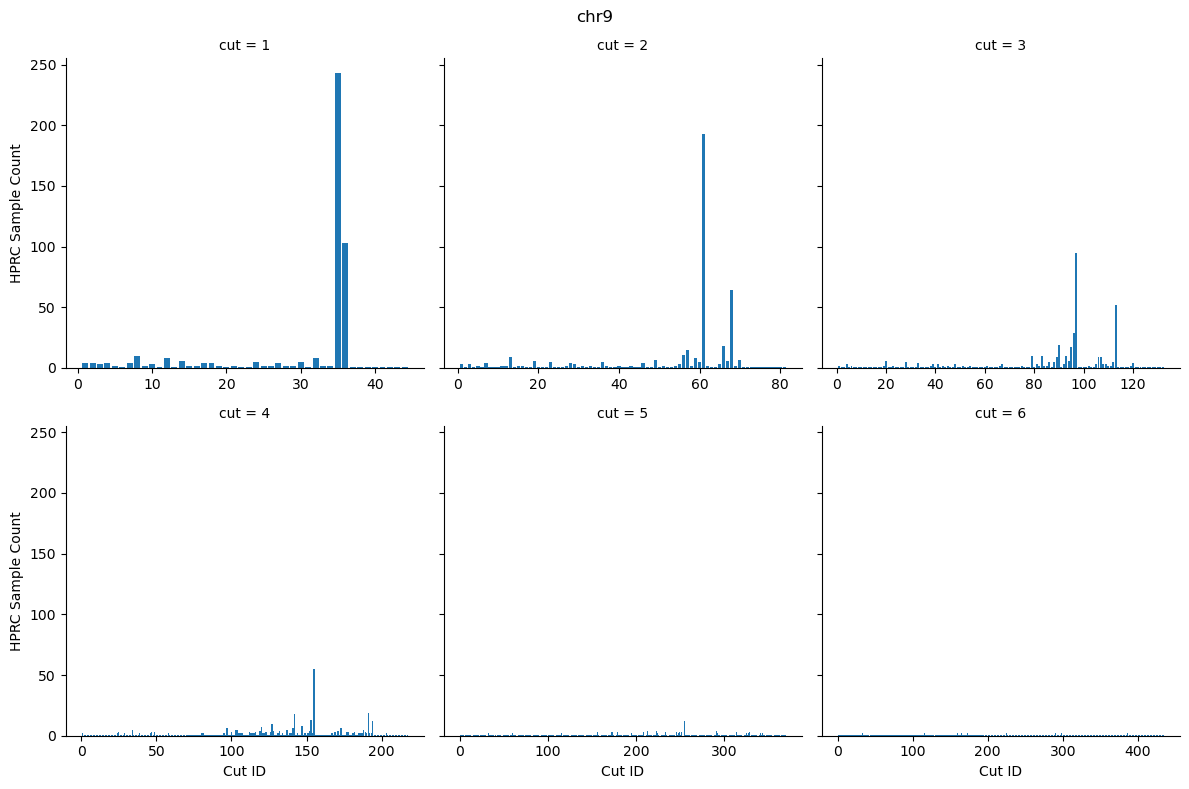

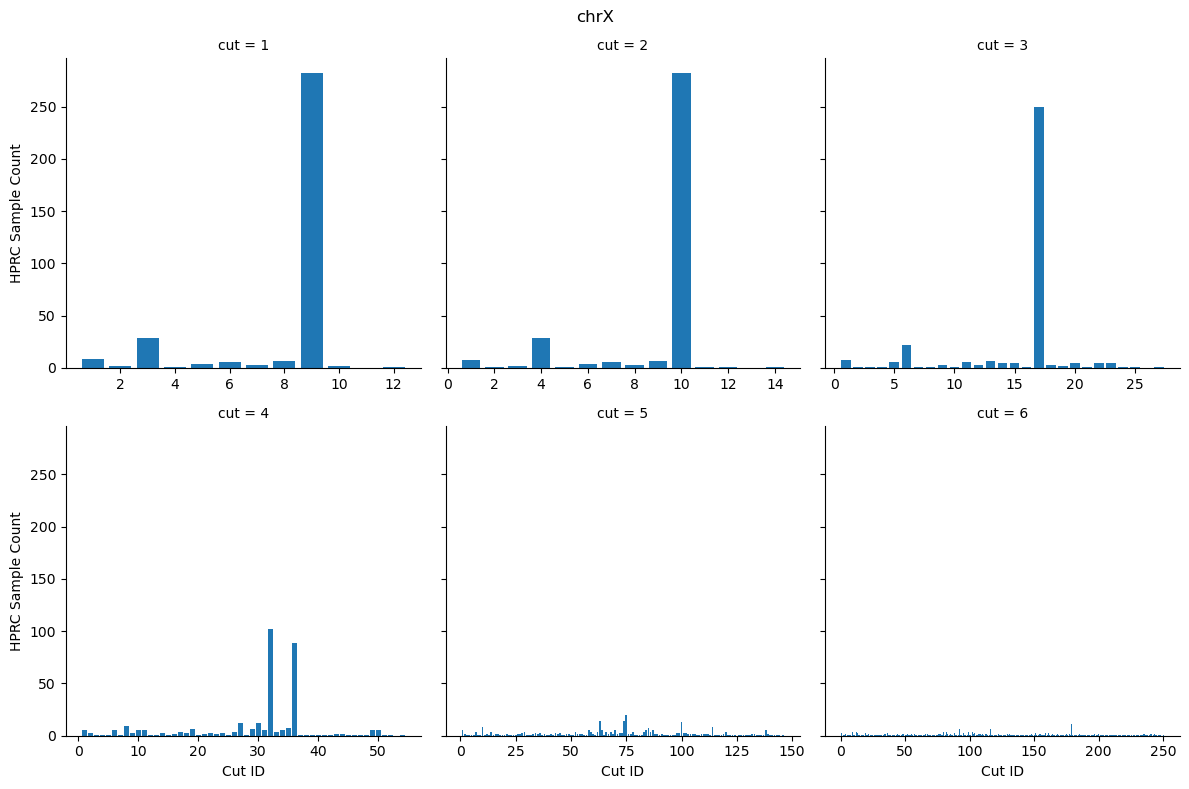

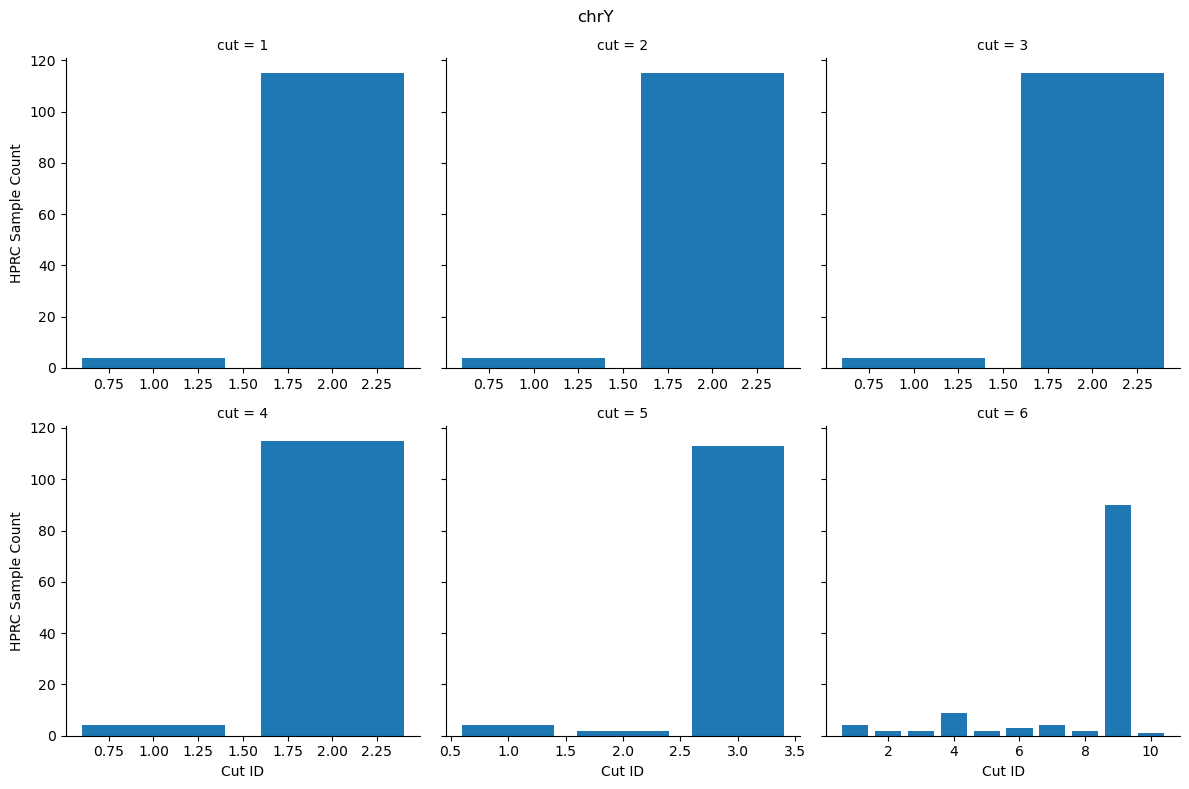

In [ ]:
for chromosome in haplotype_dict.keys():
    plot_sample_counts_chr(chromosome)

In [71]:
chromosomes = []
cuts = []
sample_sums = []
for chromosome in haplotype_dict.keys():
    for cut in haplotype_dict.get(chromosome).keys():
        sum = 0
        for cut_id in haplotype_dict.get(chromosome).get(cut).keys():
            sum += haplotype_dict.get(chromosome).get(cut).get(cut_id)
        chromosomes.append(chromosome)
        cuts.append(cut)
        sample_sums.append(sum)
data = {"chr": chromosomes, "cut": cuts, "sum of samples": sample_sums}
sample_counts_df = pd.DataFrame(data=data)
sample_counts_df.sort_values(by = ["chr", "cut"], inplace = True)
sample_counts_df.reset_index(drop = True, inplace = True)

In [ ]:
# There is variation in the sample counts in the cuts of each chromosome --> ask about how many samples we expect/where the cut counts come from
sample_counts_df.value_counts("sum of samples")

sum of samples
462    77
461    35
460    10
119     6
459     6
346     4
345     2
458     2
457     1
452     1
Name: count, dtype: int64

In [89]:
# X chromosome cut have either 345 or 346 samples
sample_counts_df.query("`sum of samples` == 346 or `sum of samples` == 345")

,chr,cut,sum of samples
132,chrX,1,346
133,chrX,2,346
134,chrX,3,346
135,chrX,4,346
136,chrX,5,345
137,chrX,6,345


In [90]:
# Y chromosome cuts have 119 samples
sample_counts_df.query("`sum of samples` == 119")

,chr,cut,sum of samples
138,chrY,1,119
139,chrY,2,119
140,chrY,3,119
141,chrY,4,119
142,chrY,5,119
143,chrY,6,119
